In [4]:
import sys
sys.path.insert(0, '..')

# Le problème max-cut : s1s5 + s2s5 + s3s5 + s4s5
# 5 noeuds, s5 (index 4) est connecté à tous les autres
ising_problem = {
    'linear':    {0: 0, 1: 0, 2: 0, 3: 0, 4: 0},
    'quadratic': {(0,4): 1, (1,4): 1, (2,4): 1, (3,4): 1}
}

print(ising_problem)

{'linear': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}, 'quadratic': {(0, 4): 1, (1, 4): 1, (2, 4): 1, (3, 4): 1}}


In [5]:
# Identifier la solution optimale par brute force
# 5 qubits → 2^5 = 32 combinaisons
best_value = float('inf')
best_solutions = []

for mask in range(1 << 5):
    # convertir les bits en spins -1/+1
    spins = [1 if (mask >> i) & 1 else -1 for i in range(5)]
    
    # calculer le coût : s1s5 + s2s5 + s3s5 + s4s5
    cost = (spins[0]*spins[4] + spins[1]*spins[4] + 
            spins[2]*spins[4] + spins[3]*spins[4])
    
    if cost < best_value:
        best_value = cost
        best_solutions = [spins]
    elif cost == best_value:
        best_solutions.append(spins)

print(f"Valeur optimale : {best_value}")
print(f"Nombre de solutions optimales : {len(best_solutions)}")
for s in best_solutions:
    print(s)

Valeur optimale : -4
Nombre de solutions optimales : 2
[1, 1, 1, 1, -1]
[-1, -1, -1, -1, 1]


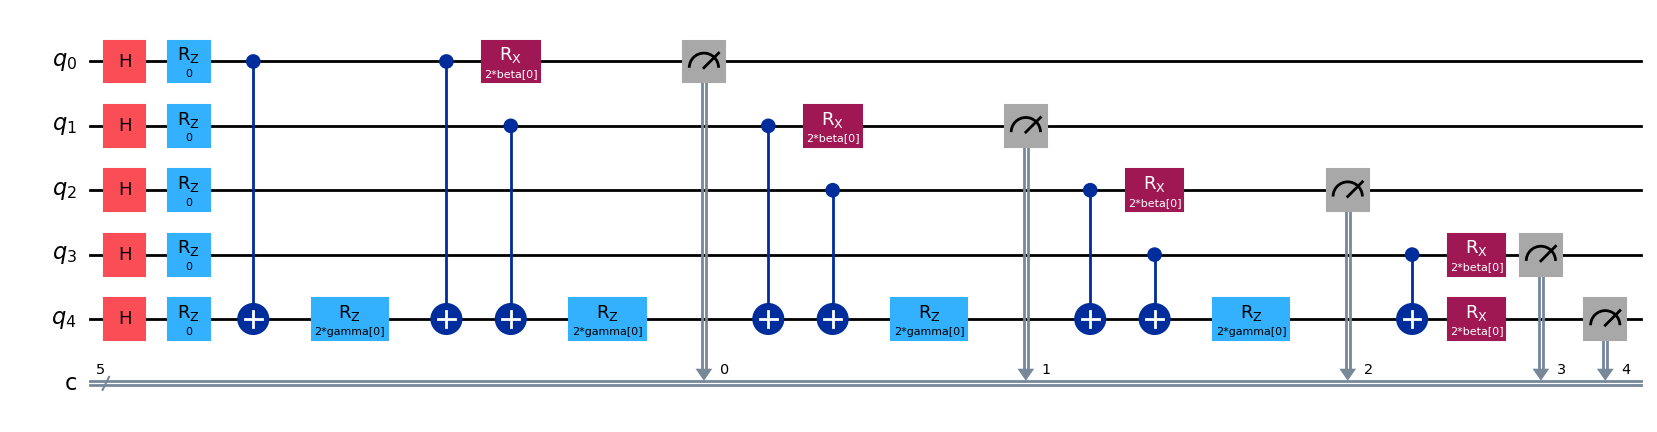

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from solver.quantum_solver.qaoa_solver.qaoa_mixers import add_ising_problem_ham, add_ising_mixer_ham

def build_qaoa_circuit(ising_problem):
    n = len(ising_problem['linear'])
    qc = QuantumCircuit(n, n)
    
    # Superposition uniforme
    for i in range(n):
        qc.h(i)
    
    # Problem Hamiltonian (Rz)
    qc, gammas = add_ising_problem_ham(qc, ising_problem, n)
    
    # Mixing Hamiltonian (Rx)
    qc, betas = add_ising_mixer_ham(qc, ising_problem, n)
    
    # Mesure
    qc.measure(range(n), range(n))
    
    return qc, gammas + betas

qc, params = build_qaoa_circuit(ising_problem)
qc.draw('mpl')

In [7]:
from qiskit_aer import AerSimulator
import numpy as np

def run_single_QAOA(angles, qc, shots=1024):
    sim = AerSimulator()
    # Associer les angles aux paramètres du circuit
    param_dict = dict(zip(qc.parameters, angles))
    bound_qc = qc.assign_parameters(param_dict)
    result = sim.run(bound_qc, shots=shots).result()
    return result.get_counts()

# Test avec des angles aléatoires
angles_test = np.random.uniform(0, np.pi, len(params))
counts = run_single_QAOA(angles_test, qc)
print(counts)

{'01001': 10, '00001': 4, '11010': 6, '00010': 5, '00011': 9, '11110': 4, '10101': 10, '00101': 7, '01011': 34, '11011': 2, '10001': 40, '01010': 7, '11100': 13, '00100': 3, '01100': 10, '00000': 53, '11101': 3, '00110': 8, '11111': 68, '10110': 10, '10010': 42, '11001': 7, '10000': 189, '11000': 55, '10100': 44, '00111': 54, '01110': 52, '10011': 7, '01111': 219, '01101': 49}


In [8]:
def get_expectation_value(counts, problem):
    total_shots = sum(counts.values())
    expectation = 0
    
    for bitstring, count in counts.items():
        # Convertir bitstring en spins -1/+1
        # little-endian : '01001' → qubit 0 = 1, qubit 1 = 0, etc.
        spins = [1 if b == '1' else -1 for b in bitstring]
        
        # Calculer le coût pour cette configuration
        cost = 0
        for (i, j), J in problem['quadratic'].items():
            cost += J * spins[i] * spins[j]
        for i, h in problem['linear'].items():
            cost += h * spins[i]
        
        expectation += cost * count / total_shots
    
    return expectation

# Test
exp_val = get_expectation_value(counts, ising_problem)
print(f"Valeur d'expectation : {exp_val:.4f}")

Valeur d'expectation : 0.9766


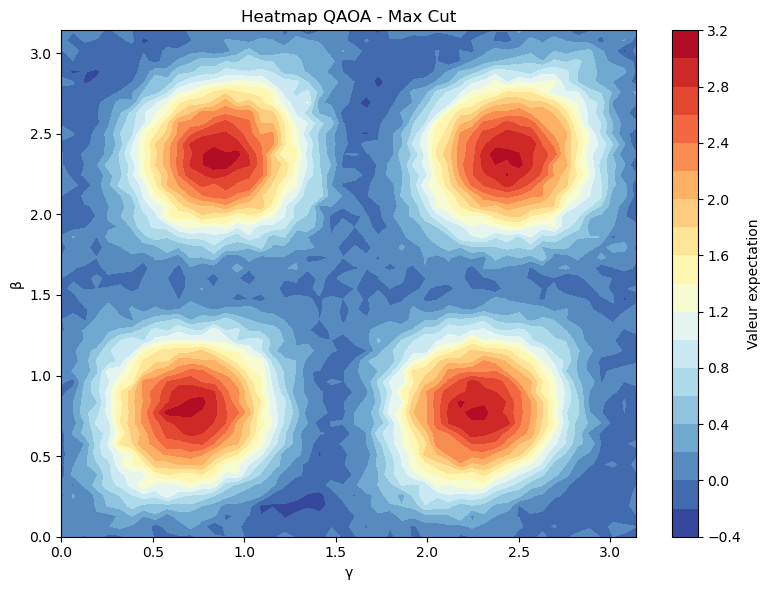

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap(ising_problem, shots=512):
    gammas = np.linspace(0, np.pi, 50)
    betas  = np.linspace(0, np.pi, 50)
    
    Z = np.zeros((50, 50))
    
    for i, gamma in enumerate(gammas):
        for j, beta in enumerate(betas):
            qc, params = build_qaoa_circuit(ising_problem)
            counts = run_single_QAOA([gamma, beta], qc, shots=shots)
            Z[j, i] = get_expectation_value(counts, ising_problem)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(gammas, betas, Z, levels=20, cmap='RdYlBu_r')
    plt.colorbar(label='Valeur expectation')
    plt.xlabel('γ')
    plt.ylabel('β')
    plt.title('Heatmap QAOA - Max Cut')
    plt.tight_layout()
    plt.show()

plot_heatmap(ising_problem)

In [10]:
from solver.quantum_solver.qaoa_solver.qaoa_optimizer import QAOALocalOptimizer
from qiskit_aer import AerSimulator

sim = AerSimulator()

optimizer = QAOALocalOptimizer(
    simulator=sim,
    gamma_bounds=(0, np.pi),
    beta_bounds=(0, np.pi),
    p=1,
    shots=1024,
    opt_method='COBYLA'
)

# Test sans optimisation
angles_test = np.random.uniform(0, np.pi, 2)
exp_val, best_sol, angles = optimizer.run_without_optimization(ising_problem, p=1, angles=angles_test)
print(f"Sans optimisation - Expectation : {exp_val:.4f}, Meilleure solution : {best_sol}")

# Test avec optimisation
exp_val, best_sol, angles = optimizer.optimize(ising_problem, p=1)
print(f"Avec optimisation - Expectation : {exp_val:.4f}, Meilleure solution : {best_sol}")

Sans optimisation - Expectation : -0.1055, Meilleure solution : [1, -1, -1, -1, -1]
Avec optimisation - Expectation : -0.0312, Meilleure solution : [1, -1, -1, 1, 1]
